# QUIZ 2

Sumber : [Link](https://www.kaggle.com/datasets/dhrubangtalukdar/global-llm-benchmark-dataset-20242026)

A comprehensive comparison dataset of leading Large Language Models (LLMs) including GPT, Claude, Gemini, Llama, Mistral, DeepSeek, Qwen and more.

This dataset aggregates benchmark performance, context window size, API pricing, and model metadata into a structured format for analysis and research.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Load data
data_analysis = pd.read_csv(r"C:\Users\Mareko\Downloads\Persentase Rumah Tangga Menurut Provinsi dan Fasilitas Tempat Buang Air Besar, 2021.csv", sep=",", skiprows=2, header=1)

df = pd.DataFrame(data_analysis)
print(df.head(11))

# Ganti '-' dengan 0 dan konversi ke numerik jika memungkinkan
df = df.replace("-", 0)
for col in df.columns[1:7]:
    df[col] = pd.to_numeric(df[col], errors='coerce')



              Unnamed: 0   2021 2021.1 2021.2 2021.3 2021.4
0                   ACEH  80.38   3.61   3.26  12.22  99.47
1         SUMATERA UTARA  88.91    2.5    1.5   7.02  99.93
2         SUMATERA BARAT  79.04   5.73   3.62  11.37  99.76
3                   RIAU   92.3   2.57   0.75   4.28   99.9
4                  JAMBI   87.9   3.38    1.5    7.2  99.97
5       SUMATERA SELATAN  82.81   5.93   3.34   7.76  99.84
6               BENGKULU  88.62   3.28   0.94   7.08  99.92
7                LAMPUNG  91.92   4.69   0.79   2.57  99.98
8   KEP. BANGKA BELITUNG  92.46   2.12   2.13   3.15  99.86
9              KEP. RIAU  94.55   4.59   0.34   0.48  99.96
10           DKI JAKARTA  86.46  10.52    2.9    0.1  99.99


## Barchart dan Pie Chart

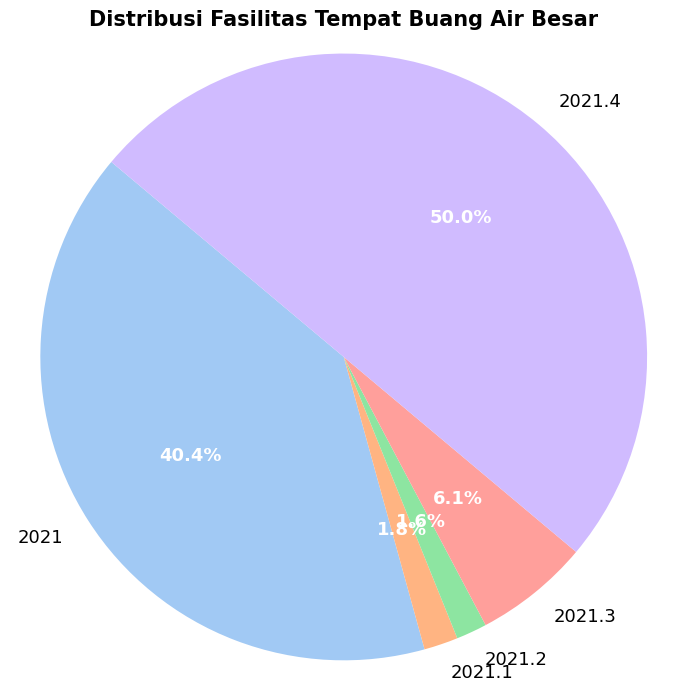

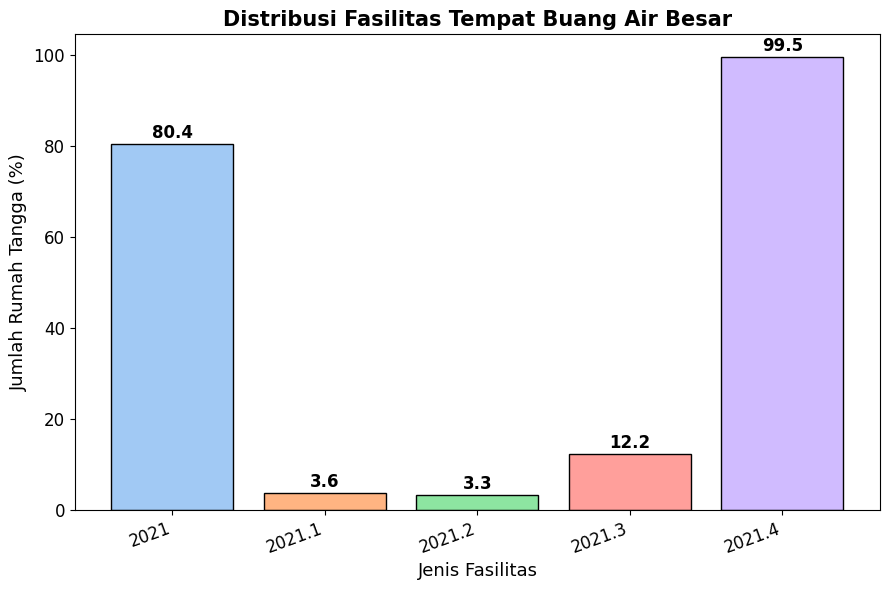

In [2]:
# Pilih kolom dan nilai untuk pie chart
Labels = df.columns[1:7]
Values = df.iloc[0, 1:7].astype(float)

# Pie chart yang lebih rapi
colors = sns.color_palette('pastel')[0:len(Labels)]
plt.figure(figsize=(7,7))
wedges, texts, autotexts = plt.pie(Values, labels=Labels, autopct='%1.1f%%', startangle=140, colors=colors, textprops={'fontsize': 12})
plt.setp(autotexts, size=13, weight="bold", color="white")
plt.setp(texts, size=13)
plt.axis('equal')
plt.title('Distribusi Fasilitas Tempat Buang Air Besar', fontsize=15, weight='bold')
plt.tight_layout()
plt.show()

# Bar chart yang lebih rapi dan informatif
plt.figure(figsize=(9,6))
bar_colors = sns.color_palette('pastel')[0:len(Labels)]
bars = plt.bar(Labels, Values, color=bar_colors, edgecolor='black')
plt.xlabel('Jenis Fasilitas', fontsize=13)
plt.ylabel('Jumlah Rumah Tangga (%)', fontsize=13)
plt.title('Distribusi Fasilitas Tempat Buang Air Besar', fontsize=15, weight='bold')
plt.xticks(rotation=20, ha='right', fontsize=12)
plt.yticks(fontsize=12)
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.5, f'{yval:.1f}', ha='center', va='bottom', fontsize=12, weight='bold')
plt.tight_layout()
plt.show()

## Histogram dan Scatter PLot

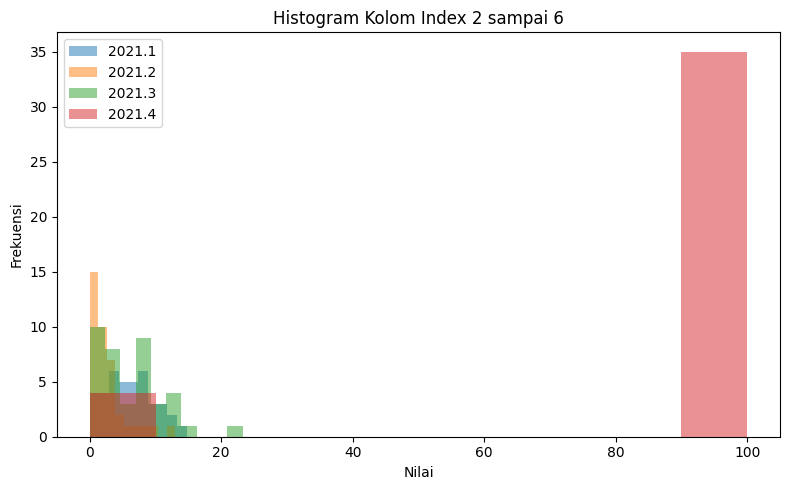

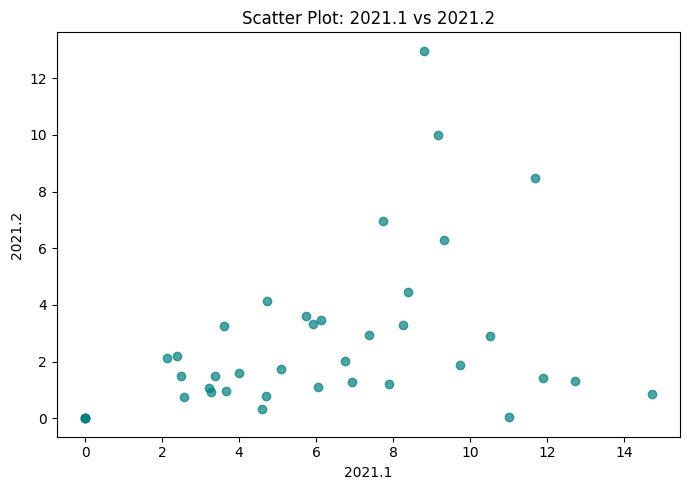

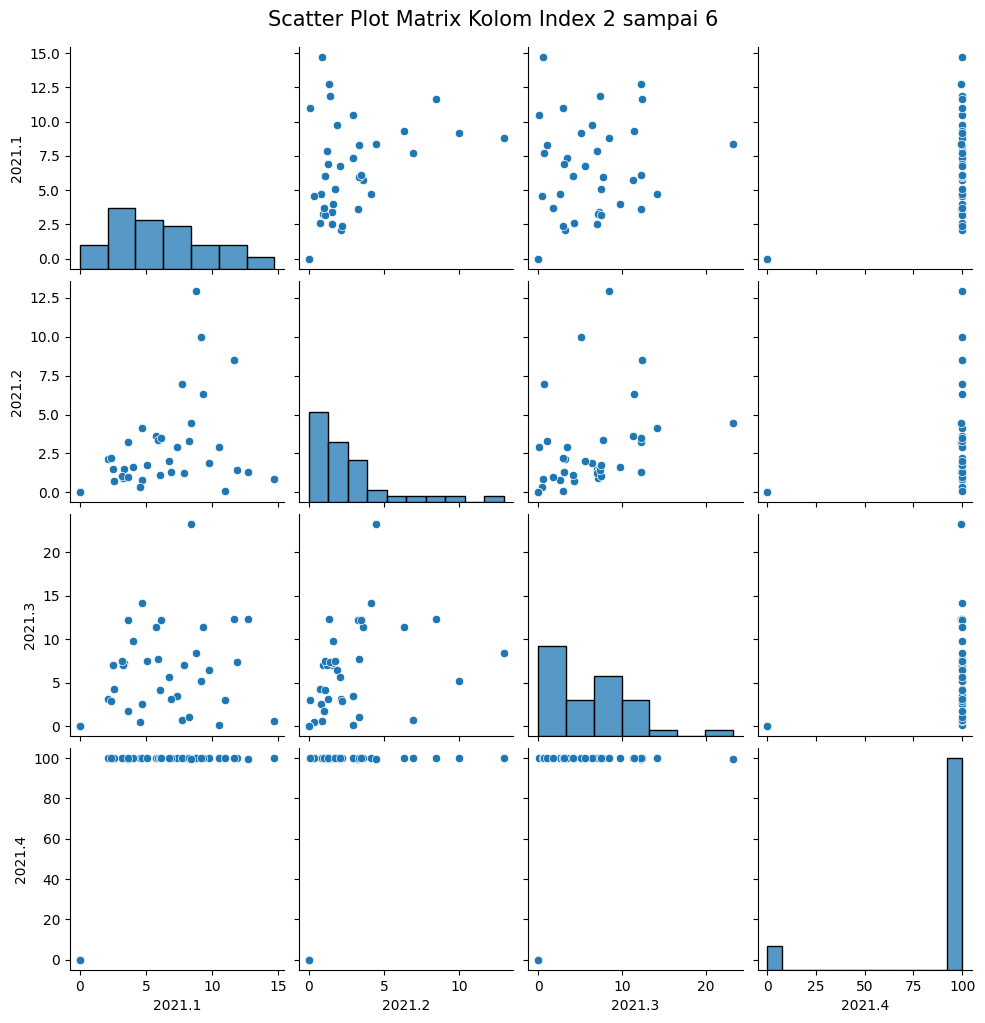

In [3]:
# Histogram sederhana untuk kolom index 2 sampai 6
plt.figure(figsize=(8,5))
for col in df.columns[2:7]:
    plt.hist(df[col].dropna().astype(float), bins=10, alpha=0.5, label=col)
plt.xlabel('Nilai')
plt.ylabel('Frekuensi')
plt.title('Histogram Kolom Index 2 sampai 6')
plt.legend()
plt.tight_layout()
plt.show()

# Scatter plot antar kolom index 2 dan 3 (contoh)
plt.figure(figsize=(7,5))
plt.scatter(df[df.columns[2]].astype(float), df[df.columns[3]].astype(float), color='teal', alpha=0.7)
plt.xlabel(df.columns[2])
plt.ylabel(df.columns[3])
plt.title(f'Scatter Plot: {df.columns[2]} vs {df.columns[3]}')
plt.tight_layout()
plt.show()

# Scatter plot matrix untuk kolom index 2 sampai 6
sns.pairplot(df[df.columns[2:7]].astype(float))
plt.suptitle('Scatter Plot Matrix Kolom Index 2 sampai 6', y=1.02, fontsize=15)
plt.show()